<a href="https://colab.research.google.com/github/Sehej15976/Applied-Data-Science/blob/main/FinalADSExperiment05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [ ]:
from google.colab import drive
# Mount the Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/ML/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [ ]:

def label_encode(df):
    label_encoder = LabelEncoder()
    for column in data.columns:
        if data[column].dtype == 'bool':
            data[column] = data[column].astype(int)
        elif data[column].dtype == 'object':
            data[column] = label_encoder.fit_transform(data[column])
    return data

df = label_encode(data)

In [ ]:
data.shape

(1470, 35)

In [ ]:
X = data.drop(columns=['Attrition'])  # Exclude the target and 'id'
y = data['Attrition']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming X and y are your original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model
lr_model = LogisticRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Accuracy scores
training_accuracy = accuracy_score(y_train, y_train_pred)
testing_accuracy = accuracy_score(y_test, y_test_pred)

# Cross-validation
cv_scores = cross_val_score(lr_model, X, y, cv=10)  # 10-fold cross-validation
mean_cv_accuracy = cv_scores.mean()

# Print the results
print(f"Training Accuracy (Before LOF): {training_accuracy:.4f}")

print(f"Testing Accuracy (Before LOF): {testing_accuracy:.4f}")
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy (Before LOF): {mean_cv_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Training Accuracy (Before LOF): 0.8325
Testing Accuracy (Before LOF): 0.8673
Cross-Validation Accuracy Scores: [0.84353741 0.83673469 0.83673469 0.83673469 0.84353741 0.84353741
 0.82993197 0.84353741 0.84353741 0.84353741]
Mean Cross-Validation Accuracy (Before LOF): 0.8401


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
# prompt: apply LOF outlier detection

from sklearn.neighbors import LocalOutlierFactor

# Assuming X is your feature data (as defined in your previous code)
lof = LocalOutlierFactor( contamination=0.1) # Adjust parameters as needed
y_pred = lof.fit_predict(X)

# Identify outliers
outliers = X[y_pred == -1]

# Print or visualize the outliers
print("Number of outliers detected:", len(outliers))
print("Outliers:\n", outliers)

# Optionally, you can remove the outliers from your dataset
X_cleaned = X[y_pred == 1]
print("\nShape of data before removing outliers:", X.shape)
print("Shape of data after removing outliers:", X_cleaned.shape)

Number of outliers detected: 147
Outliers:
       Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
1      49               1        279           1                 8          1   
2      37               2       1373           1                 2          2   
4      27               2        591           1                 2          1   
7      30               2       1358           1                24          1   
11     29               2        153           1                15          2   
...   ...             ...        ...         ...               ...        ...   
1457   40               2       1194           1                 2          4   
1458   35               2        287           1                 1          4   
1459   29               2       1378           1                13          2   
1461   50               2        410           2                28          3   
1462   39               2        722           2                2

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import KFold  # Changed from StratifiedKFold
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize variables for tracking best parameters
best_n_neighbors = 0
best_score = float('-inf')
n_neighbors_range = range(3, 31)

# Cross-validation setup
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Store cross-validation scores
cv_scores = []

# Loop to find best n_neighbors
for n_neighbors in n_neighbors_range:
    # Temporary storage for fold scores
    fold_scores = []

    # Perform cross-validation
    for train_index, test_index in cv.split(X_scaled):
        # Split the data
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]

        # Apply LOF
        lof = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=0.1,  # Adjust based on your data
            novelty=False
        )

        # Predict outliers
        y_pred = lof.fit_predict(X_train)

        # Calculate score (simple metric: number of outliers)
        # You can customize this scoring
        score = -np.sum(y_pred == -1)
        fold_scores.append(score)

    # Average score for this n_neighbors
    avg_score = np.mean(fold_scores)

    # Update best parameters if needed
    if avg_score > best_score:
        best_score = avg_score
        best_n_neighbors = n_neighbors

# Print best n_neighbors
print(f"Best n_neighbors: {best_n_neighbors}")

# Apply LOF with best parameters
lof = LocalOutlierFactor(
    n_neighbors=best_n_neighbors,
    contamination=0.1,
    novelty=False
)

# Predict outliers on entire dataset
y_pred = lof.fit_predict(X_scaled)

# Identify and separate outliers
outliers = X[y_pred == -1]
X_cleaned = X[y_pred == 1]


# Align the cleaned X with y to create y_cleaned
y_cleaned = y[y_pred == 1]

# Print results


print("Number of outliers detected:", len(outliers))
print("\nShape of data before removing outliers:", X.shape)
print("Shape of data after removing outliers:", X_cleaned.shape)
print("Shape of cleaned targets:", y_cleaned.shape)

Best n_neighbors: 3
Number of outliers detected: 147

Shape of data before removing outliers: (1470, 34)
Shape of data after removing outliers: (1323, 34)
Shape of cleaned targets: (1323,)


In [ ]:
print(X_cleaned)

      Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
1      49               1        279           1                 8          1   
2      37               2       1373           1                 2          2   
3      33               1       1392           1                 3          4   
4      27               2        591           1                 2          1   
5      32               1       1005           1                 2          2   
...   ...             ...        ...         ...               ...        ...   
1465   36               1        884           1                23          2   
1466   39               2        613           1                 6          1   
1467   27               2        155           1                 4          3   
1468   49               1       1023           2                 2          3   
1469   34               2        628           1                 8          3   

      EducationField  Emplo

In [ ]:
print(y_cleaned)

1       0
2       1
3       0
4       0
5       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1323, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Check the shape of the input features and labels
print(f"X_cleaned shape: {X_cleaned.shape}")
print(f"y shape: {y.shape}")

# Ensure both arrays have the same number of samples
if X_cleaned.shape[0] != y_cleaned.shape[0]:
    raise ValueError("X_cleaned and y must have the same number of samples.")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression()  # Increase max_iter as needed
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Accuracy scores
training_accuracy = accuracy_score(y_train, y_train_pred)
testing_accuracy = accuracy_score(y_test, y_test_pred)

# Cross-validation
cv_scores = cross_val_score(lr_model, X_cleaned, y_cleaned, cv=10)

# Print the results
print(f"Training Accuracy: {training_accuracy:.4f}")
print(f"Testing Accuracy: {testing_accuracy:.4f}")
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {np.mean(cv_scores):.4f}")


X_cleaned shape: (1323, 34)
y shape: (1470,)
Training Accuracy: 0.8450
Testing Accuracy: 0.8302
Cross-Validation Accuracy Scores: [0.85714286 0.84210526 0.84210526 0.84090909 0.84848485 0.84848485
 0.83333333 0.82575758 0.84090909 0.84090909]
Mean Cross-Validation Accuracy: 0.8420


In [ ]:
# # prompt: print roc and plot roc graph

# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve, auc

# # Assuming y_test and y_test_pred are defined from your previous code
# # y_test: True labels for the test set
# # y_test_pred: Predicted probabilities for the test set


# # Get predicted probabilities for the positive class
# y_test_prob = lr_model.predict_proba(X_test)[:, 1]

# # Calculate ROC curve
# fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# # Calculate AUC
# roc_auc = auc(fpr, tpr)

# # Print ROC AUC
# print(f"ROC AUC: {roc_auc}\n\n")


# # Plot ROC curve
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic')
# plt.legend(loc="lower right")
# plt.show()


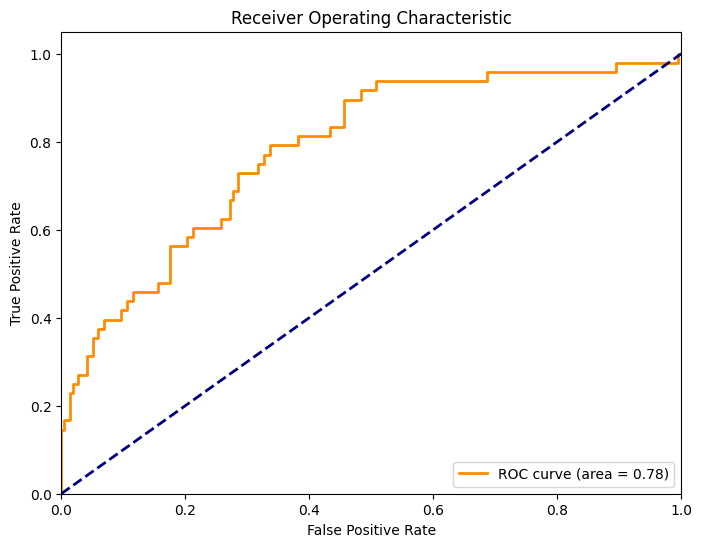

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Assuming X_cleaned and y_cleaned are your data
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'penalty': ['l1', 'l2']  # Regularization type
}

# Create a Logistic Regression model
lr_model = LogisticRegression(solver='liblinear')  # Use liblinear for l1 penalty

# Create a GridSearchCV object
grid_search = GridSearchCV(lr_model, param_grid, scoring='roc_auc', cv=10)

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_lr_model = grid_search.best_estimator_

# Predict probabilities on the test set
y_test_prob = best_lr_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Best Parameters (Logistic Regression): {'C': np.float64(0.1), 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation Accuracy: 0.8210154429735042
AUC-ROC Score (Test Set): 0.6233
AUC-ROC Score (Test Set): 0.7838


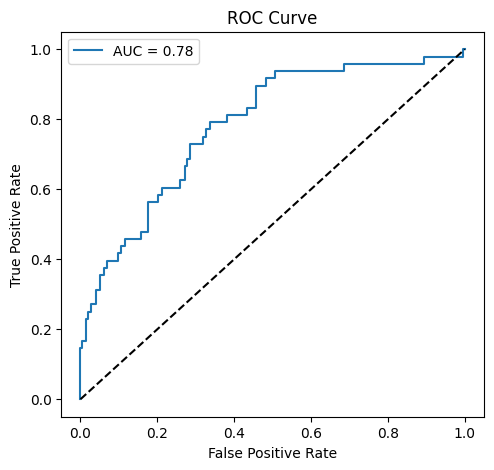

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Assuming X_cleaned and y_cleaned are your data
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV

# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'C': np.logspace(-3, 3, 7), # Wider range of C values
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=10, scoring='roc_auc')
grid_search.fit(X_scaled, y)  # Consider using X_train, y_train to avoid data leakage

# Print Best Parameters & Best Accuracy
print("Best Parameters (Logistic Regression):", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Best Model Evaluation
y_proba_test = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba_test)
print(f"AUC-ROC Score (Test Set): {roc_auc:.4f}")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"AUC-ROC Score (Test Set): {roc_auc:.4f}")
plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()